# Codice generale dell Esperienza "Dualismo Onda-Particella"

## Definizioni preliminari

In [154]:
#IMPORTAZIONE DELLE LIBRERIE

import numpy as np
import random as rd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from scipy.optimize import curve_fit
import matplotlib.ticker as mtick

In [155]:
#CONFIGURAZIONE GRAFICI
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans'] # Ordine di preferenza
plt.rcParams['font.weight'] = 'bold'          # Grassetto per tutto il testo
plt.rcParams['axes.labelweight'] = 'bold'     # Grassetto per le etichette degli assi
plt.rcParams['axes.titleweight'] = 'bold'     # Grassetto per il titolo
plt.rcParams['mathtext.fontset'] = 'custom'   # Per rendere bold anche la matematica
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.bf'] = 'sans:bold'


In [156]:
#DEFINIZIONI COSTANTI E PERCORSO
percorso="immagini/"

#costanti varie
h=6.62607015*10**-34
m_e=9.109383*10**-31
e=1.602176634*10**-19
d_10=0.213*10**-9
D_11=0.1239*10**-9
L=125*10**-3
L_err=2e-3
R=130e-3

titoli=False

In [157]:
#DEFINIZIONI FUNZIONI UTILI
# funzione da gemini, concettualmente semplice ma non ho ancora masterato le maschere in PY
def taglia_dati(x, y, x_min, x_max):
    """
    Sotto-campiona gli array x e y in base a un intervallo definito su x.
    
    Parametri:
    x (np.ndarray): Array delle coordinate indipendenti (es. raggio).
    y (np.ndarray): Array delle coordinate dipendenti (es. intensità).
    x_min (float): Valore minimo dell'intervallo.
    x_max (float): Valore massimo dell'intervallo.
    
    Ritorna:
    tuple: (x_filtrato, y_filtrato) come np.ndarray.
    """
    # Creazione di una maschera booleana
    maschera = (x >= x_min) & (x <= x_max)
    
    # Applicazione della maschera a entrambi gli array
    return x[maschera], y[maschera]

# Esempio di utilizzo:
# r = np.linspace(0, 10, 100)
# i = np.exp(-r**2)
# r_tagliato, i_tagliato = taglia_dati(r, i, 2.0, 5.0)



def media_mobile_conv(y, finestra):
    """
    Calcola la media mobile utilizzando la convoluzione.
    y: array dei dati (intensità).
    finestra: numero di punti della finestra di media.
    """
    kernel = np.ones(finestra) / finestra
    # 'same' mantiene la dimensione dell'array originale
    return np.convolve(y, kernel, mode='same')

# Prima Parte

### Dati presi da Excel
Deliberatamente copiati e incollati

In [158]:
#DATI
# # Corrente^2 [A^2]
corrente_quadro = np.array([
    0.004775, 0.005663, 0.005715, 0.006373, 
    0.006659, 0.006989, 0.007090, 0.007656
])

# Differenza di potenziale d.d.p [V]
voltaggi = np.array([
    102.97, 115.76, 120.50, 128.59, 
    135.00, 142.50, 145.30, 153.90
])

# Errore Corrente^2 [A^2]
corrente_quadro_err = np.array([
    0.000014, 0.000015, 0.000015, 0.000016, 
    0.000016, 0.000017, 0.000017, 0.000018
])

# Errore d.d.p [V]
voltaggi_err = np.array([
    0.1, 0.1, 0.1, 0.1, 
    0.1, 0.1, 0.1, 0.1
])

### FIT
Eseguito sia con che senza il passaggio per l'origine.

In [159]:
#DEFINIZIONE MODELLI DI FIT

def retta_passante_per_origine(x, m): #hehe passante
    return m*x

def retta_generica(x, m, q):
    return m*x+q

In [160]:
#FIT

# Per usare curve_fit con errori su X, calcoliamo un errore efficace:
# sigma_tot = sqrt(err_y^2 + (m * err_x)^2)
# Poiché non conosciamo 'm', facciamo una prima stima veloce
m_stima = np.mean(voltaggi / corrente_quadro)
sigma_efficace = np.sqrt(voltaggi_err**2 + (m_stima * corrente_quadro_err)**2)


popt_fit_passante, pcov_fit_passante = curve_fit(retta_passante_per_origine, corrente_quadro, voltaggi, sigma=sigma_efficace, absolute_sigma=False)
m_fit_passante = popt_fit_passante[0]
m_fit_passante_err = np.sqrt(pcov_fit_passante[0,0])

popt_fit, pcov_fit = curve_fit(retta_generica, corrente_quadro, voltaggi, sigma=sigma_efficace, absolute_sigma=False)

# Estrazione parametri
m_fit, q_fit = popt_fit

p_fit_err = np.sqrt(np.diag(pcov_fit))
m_fit_err = p_fit_err[0]
q_fit_err = p_fit_err[1]

print('-----------------------------------RISULTATI DEI FIT----------------------------\n')
print(f'Pendenza nel caso passante\t{m_fit_passante} ± {m_fit_passante_err}\n')
print(f'Pendenza nel caso non passante\t{m_fit} ± {m_fit_err}\n')
print(f'Intercetta nel caso non passante\t{q_fit} ± {q_fit_err}\n')


-----------------------------------RISULTATI DEI FIT----------------------------

Pendenza nel caso passante	20509.967184441735 ± 163.09251684353686

Pendenza nel caso non passante	17961.084082259164 ± 683.1309326018788

Intercetta nel caso non passante	16.230816931524952 ± 4.306881307107357



### Grafico

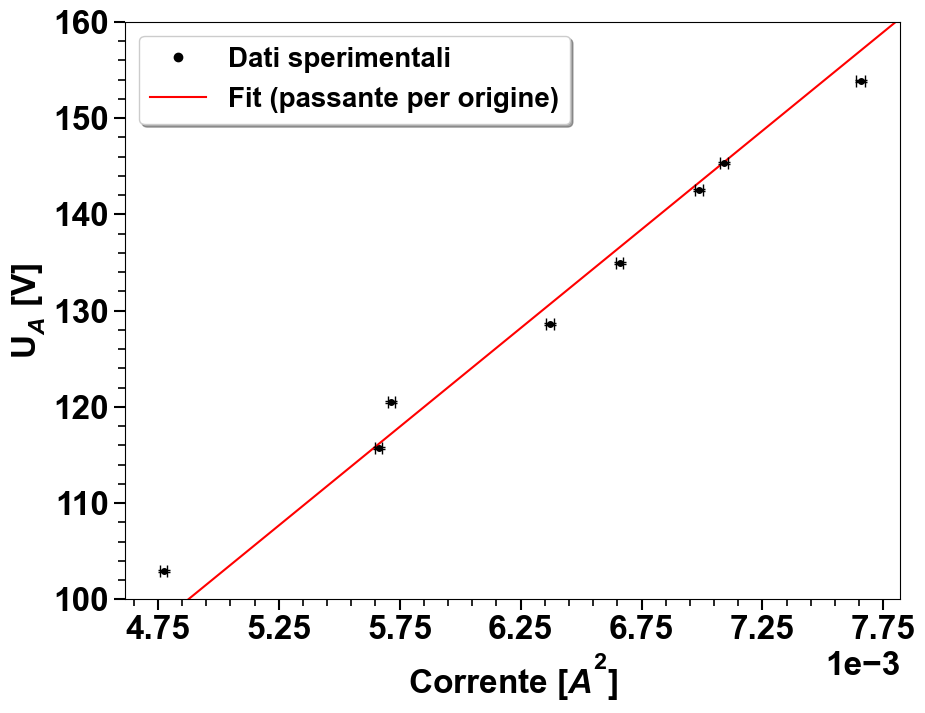

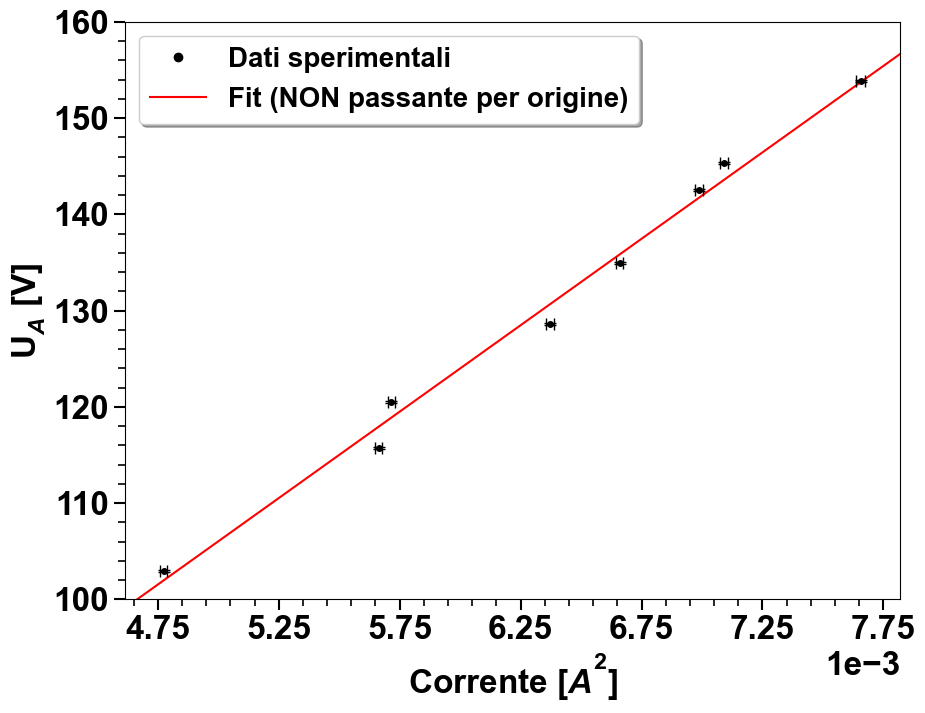

In [161]:
#GRAFICO

plt.figure(figsize=(10, 7.5))
if titoli:
    plt.title('Dualismo Onda-Particella - Prima Parte', fontsize=30)
# 1. Dati sperimentali (zorder=2 li mette sopra la linea)
# Non mettiamo la label qui per evitare il simbolo "sporco" in legenda
plt.errorbar(corrente_quadro, voltaggi, xerr=corrente_quadro_err, yerr=voltaggi_err, fmt='ko', capsize=4, zorder=2, ms=4)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'ko', label='Dati sperimentali')

# 3. Calcolo e disegno del Fit
# Usiamo i limiti attuali dei dati per estendere la linea di fit
x_min, x_max = plt.xlim()
x_fit = np.linspace(x_min, x_max, 100)
plt.plot(x_fit, retta_passante_per_origine(x_fit, m_fit_passante), 'r-', label='Fit (passante per origine)', zorder=1)

# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.xaxis.get_offset_text().set_fontsize(24)  # Qui decidi quanto farlo grande
ax.xaxis.get_offset_text().set_fontweight('bold') # Puoi anche farlo grassetto

# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(0.00475, 0.0078, 0.0005) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(100, 170, 10)
ax.set_yticks(tick_y_manuali)

# Forza la notazione scientifica (esponenziale) sull'asse X
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

# --- CONFIGURAZIONE ESTETICA FINALE ---
plt.xlim(x_min, x_max)
plt.ylim(100, 160)

# Titoli e font aumentati per massima chiarezza
plt.xlabel("Corrente [$A^2$]", fontsize=24)
plt.ylabel("U$_A$ [V]", fontsize=24)

ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)

# Legenda pulita (grazie al punto fantasma di riga 11)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=20)
# Salva il file prima di mostrarlo
#plt.savefig("GRAFICI/Fit_lineare.png", dpi=300, bbox_inches='tight')
plt.show()
plt.figure(figsize=(10, 7.5))

if titoli:
    plt.title('Dualismo Onda-Particella - Fit libero', fontsize=30)

# 1. Dati sperimentali (zorder=2 li mette sopra la linea)
# Non mettiamo la label qui per evitare il simbolo "sporco" in legenda
plt.errorbar(corrente_quadro, voltaggi, xerr=corrente_quadro_err, yerr=voltaggi_err, fmt='ko', capsize=4, zorder=2, ms=4)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'ko', label='Dati sperimentali')

# 3. Calcolo e disegno del Fit
# Usiamo i limiti attuali dei dati per estendere la linea di fit
x_min, x_max = plt.xlim()
x_fit = np.linspace(x_min, x_max, 100)
plt.plot(x_fit, retta_generica(x_fit, m_fit, q_fit), 'r-', label='Fit (NON passante per origine)', zorder=1)

# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.xaxis.get_offset_text().set_fontsize(24)  # Qui decidi quanto farlo grande
ax.xaxis.get_offset_text().set_fontweight('bold') # Puoi anche farlo grassetto

# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(0.00475, 0.0078, 0.0005) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(100, 170, 10)
ax.set_yticks(tick_y_manuali)

# Forza la notazione scientifica (esponenziale) sull'asse X
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

# --- CONFIGURAZIONE ESTETICA FINALE ---
plt.xlim(x_min, x_max)
plt.ylim(100, 160)

# Titoli e font aumentati per massima chiarezza
plt.xlabel("Corrente [$A^2$]", fontsize=24)
plt.ylabel("U$_A$ [V]", fontsize=24)

ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)

# Legenda pulita (grazie al punto fantasma di riga 11)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=20)
# Salva il file prima di mostrarlo
#plt.savefig("GRAFICI/Fit_lineare.png", dpi=300, bbox_inches='tight')
plt.show()

### Risultati

fit passante per zero	 202243857522.18442 	pm	 4824648345.088565
fit libero		 177109933790.2364 	pm	 20208569876.412727
valore teorico		 175882014621.62695


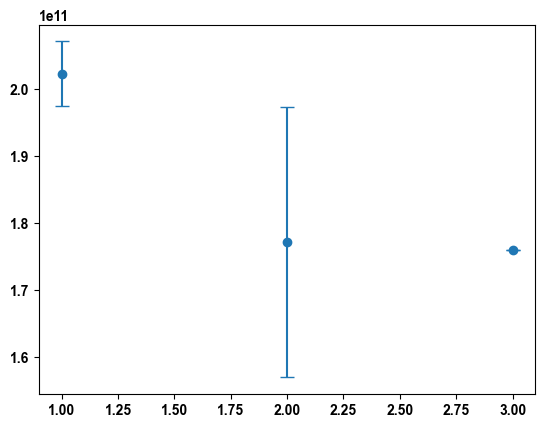

In [162]:
#VALUTAZIONE DEL RAPPORTO e/m

K=4.17e-3
R_desmos=0.108
R_desmos_err=0.002
alfa=(R_desmos**2)*(K**2)/2
alfa_err=(R_desmos*K**2)*R_desmos_err
e_su_m_fit_passante=m_fit_passante/alfa
e_su_m_fit_passante_err=np.sqrt(
    (m_fit_passante_err*3/alfa)**2
    +(m_fit_passante*alfa_err/alfa**2)
)
e_su_m_fit=m_fit/alfa
e_su_m_fit_err=np.sqrt(
    (m_fit_err*3/alfa)**2
    +(m_fit*alfa_err/alfa**2)
)
e_su_m_teorico=e/m_e
print('fit passante per zero\t', e_su_m_fit_passante,'\tpm\t',e_su_m_fit_passante_err)
print('fit libero\t\t', e_su_m_fit,'\tpm\t',e_su_m_fit_err)
print('valore teorico\t\t', e_su_m_teorico)

plt.errorbar([1,2,3], [e_su_m_fit_passante, e_su_m_fit, e_su_m_teorico], yerr=[e_su_m_fit_passante_err, e_su_m_fit_err, 0], fmt='o', capsize=5)
plt.show()

Risultati:
$$\frac{e}{m}_{teorico}=            1.75882000838 \times 10^{11} C/kg$$
$$\frac{e}{m}_{fit-passante}=      ( 2.02243857522 \pm  0.05)\times 10^{11} C/kg$$
$$\frac{e}{m}_{fit-non-passante}=  ( 1.77109933790 	 \pm  0.2 )\times 10^{11} C/kg$$

# Seconda Parte

## Funzione di analisi foto (4-Fold)

In [163]:
#DEFINIZIONE FUNZIONE ANALISI

def analisi(nome_file):
    
    #estrae dal nome i dati
    voltaggio_text=nome_file[0:4]
    voltaggio=float(voltaggio_text)

    set_text=nome_file[5:-5]
    print('SET ',set_text)
    print('VOLTAGGIO ', voltaggio)
    #apre l'immagine e la converte in bianco e nero
    immagine=Image.open(percorso+nome_file)
    matrice_a_colori=np.array(immagine)
    matrice_bn=np.float64(np.array(immagine.convert('L')))
    
    #trova le coordinate riga colonna del massimo di intensità
    old_coords = np.unravel_index(np.argmax(matrice_bn), matrice_bn.shape)
    old_R_centro=old_coords[0]
    old_C_centro=old_coords[1]

    #lato medio dell'immagine (perché non è esattamente quadrata)
    lato_medio=np.mean(matrice_bn.shape)

    #rapporto per convertire in seguito
    pixel_in_mm=100/np.mean(matrice_bn.shape)

    #taglio in modo tale che il centro trovato corrisponda al centro della matrice
    cut_matrice_bn=matrice_bn[int(old_R_centro-0.4*lato_medio):int(old_R_centro+0.4*lato_medio), int(old_C_centro-0.4*lato_medio):int(old_C_centro+0.4*lato_medio)]

    #coordinate del nuovo centro
    coords = np.unravel_index(np.argmax(cut_matrice_bn), cut_matrice_bn.shape)
    R_centro=coords[0]
    C_centro=coords[1]

    #lato della nuova matrice tagliata
    lato=cut_matrice_bn.shape[0]

    #vecchio plot
    '''    
    plt.scatter(C_centro, R_centro, marker='X', c='r', s=0.5)
    plt.imshow(cut_matrice_bn)
    '''

    # ''asse delle x'' ovvero indice di colonna
    R_Mesh =np.linspace(0, lato-1, lato)

    #array con la riga e la colonna passanti per il centro
    Intensita_riga_centro=cut_matrice_bn[R_centro, :]
    Intensita_colonna_centro=cut_matrice_bn[:, C_centro]

    #valore nel centro
    Intensita_centro=cut_matrice_bn[R_centro,C_centro]

    #vecchio plot
    ''' 
    plt.plot(R_Mesh,Intensita_riga_centro)
    plt.plot(R_Mesh,Intensita_colonna_centro)
    plt.legend(('riga', 'colonna'))
    plt.title('Intensità passante per il centro (hehe passante)')
    plt.scatter(C_centro,
                Intensita_centro,
                c='r')
    '''

    #sovrapposizione
    somma=Intensita_colonna_centro+Intensita_riga_centro
    
    #fold della destra sulla sinistra
    somma_dx=np.flip(somma[:R_centro])
    somma_sx=somma[R_centro:]
    if(somma_sx.shape!=somma_dx.shape):
        somma_sx=np.append(somma_sx, (0))
    somma_fold=somma_dx+somma_sx
    somma_fold=somma_fold/max(somma_fold)
    
    '''    #plot del risultato
    plt.title(voltaggio_text+' Volt ---'+' Set '+set_text)
    plt.plot(R_Mesh[:R_centro], somma_fold)
    plt.ylim(0,1)'''

    print('COORDINATE CENTRO ', R_centro, C_centro, '\n')
    return R_Mesh[:R_centro], somma_fold, voltaggio, set_text, pixel_in_mm, cut_matrice_bn, R_centro, C_centro

#RITORNA TUTTO QUELLO CHE SERVE PER PLOTTARE

## Run dell'analisi su tutti i file (set v) e raccolta risultati

In [164]:
#CARICO TUTTI I RISULTATI IN UN DIZIONARIO DI DIZIONARI

risultati={}

for nome_file in os.listdir(percorso):
    risultati[nome_file]={}

    x, y, v, s, c, M, RC, CC = analisi(nome_file)
    
    risultati[nome_file]['R_Mesh']=x
    risultati[nome_file]['Fold']=y
    risultati[nome_file]['Voltaggio']=v
    risultati[nome_file]['Set']=s
    risultati[nome_file]['Pixel_in_mm']=c

    risultati[nome_file]['Matrice']=M
    risultati[nome_file]['Riga_Centro']=RC
    risultati[nome_file]['Colonna_Centro']=CC

    '''plt.title(str(v)+' Volt ---'+' Set '+s)
    plt.plot(x, y)
    plt.ylim(0,1)
    plt.show()'''

SET  v
VOLTAGGIO  3400.0
COORDINATE CENTRO  493 493 

SET  v
VOLTAGGIO  3800.0
COORDINATE CENTRO  493 493 

SET  v
VOLTAGGIO  4100.0
COORDINATE CENTRO  492 492 

SET  v
VOLTAGGIO  4350.0
COORDINATE CENTRO  492 492 

SET  v
VOLTAGGIO  4500.0
COORDINATE CENTRO  493 493 



## Localizzazione massimi locali
All'interno delle regioni di ricerca definite dalle rette verticali

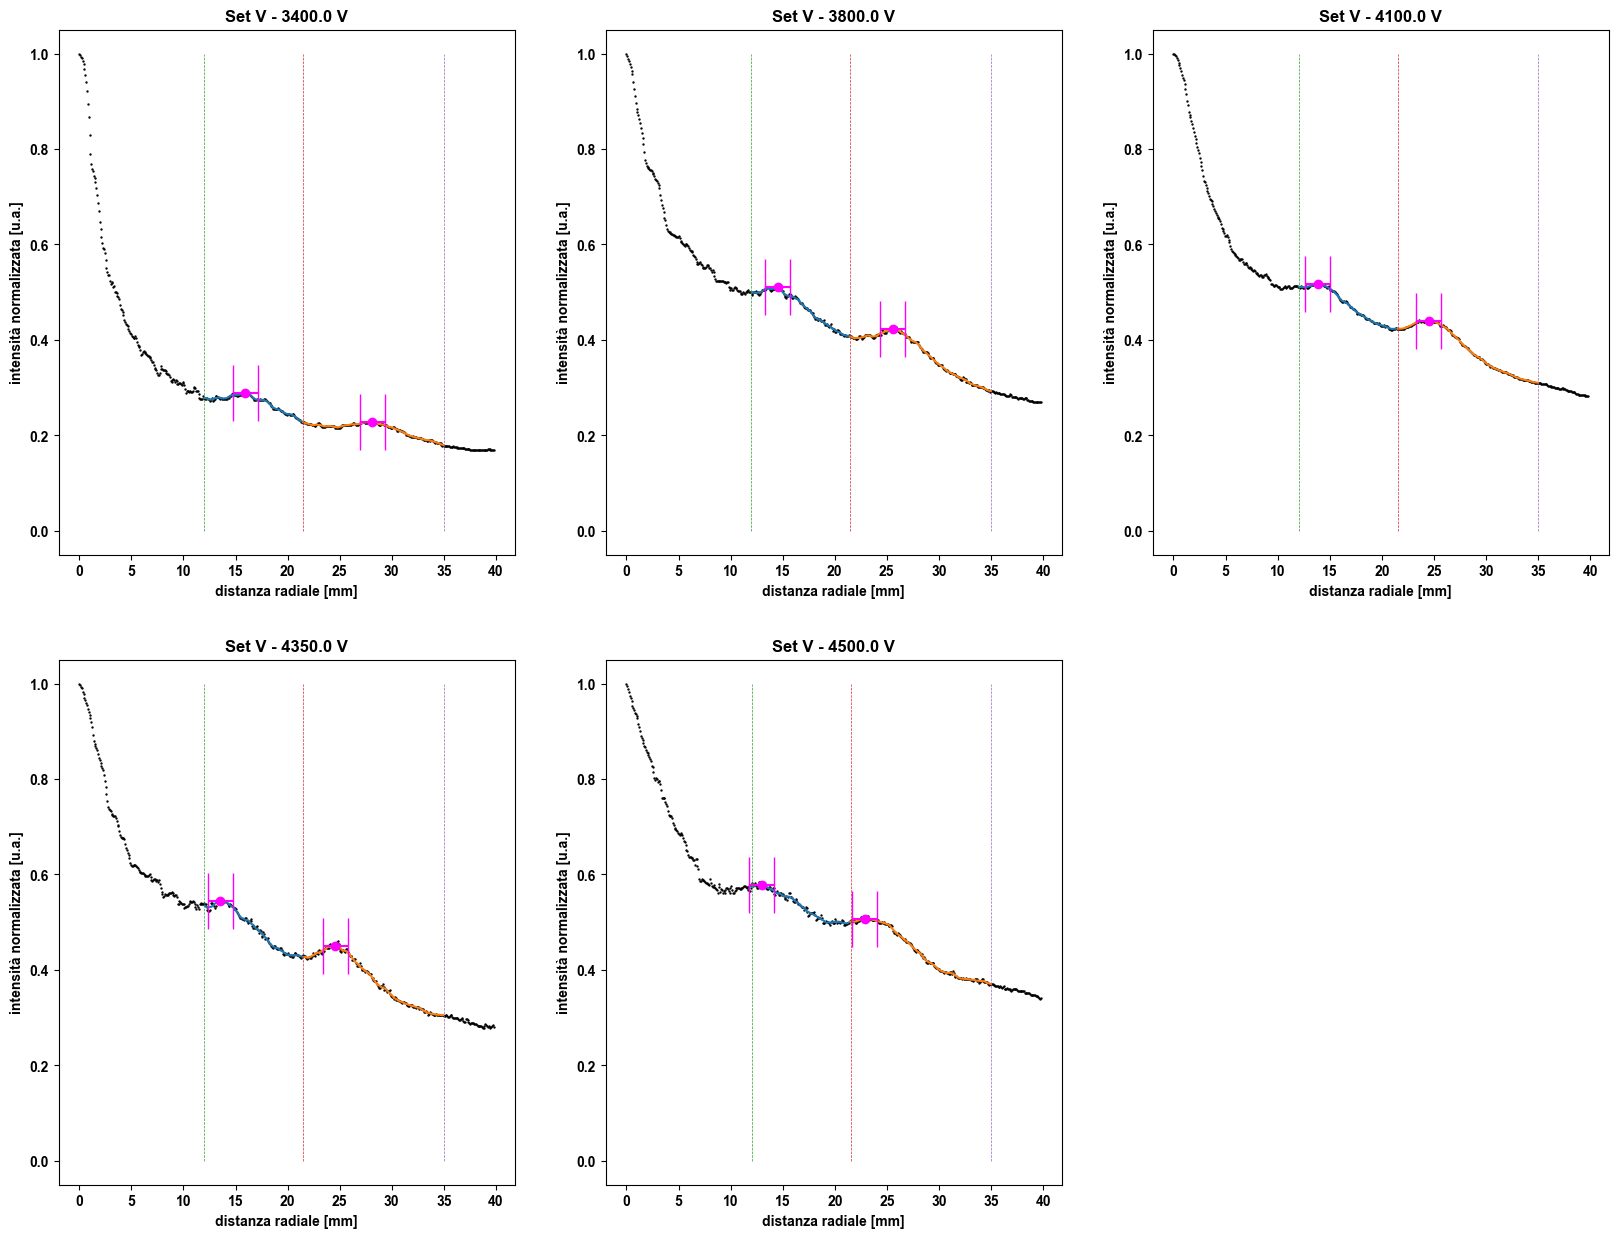

In [165]:
#LOCALIZZAZIONE GRAFICA DEI MASSIMI

#DEFINIZIONI ARBITRARIE (GRAFICHE):
i=0
retta_1=12
retta_2=21.5
retta_3=35
err=1.2
#apertura figura
plt.figure(figsize=(20,15), dpi=100)
#plt.axes()
#if titoli:

#ciclo for su tutti i dati
for file in risultati:    
        #trimming dei dati e conversione delle x in mm
        x=risultati[file]['R_Mesh'][:-2]
        x=x*risultati[file]['Pixel_in_mm']
        y=risultati[file]['Fold'][:-2]
        
        #array di y passato sotto la media mobile
        y_med=media_mobile_conv(y, 9)

        #fette di dati tra le rette di soglia definite arbitrariamente
        cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
        cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, retta_3)
        
        #indici dei massimi locali all'interno delle fette
        max_1=np.argmax(cut_1_y)
        max_2=np.argmax(cut_2_y)

        #carica i due massimi nel dizionario di dizionari                
        risultati[file]['R10']=cut_1_x[max_1]/1000
        risultati[file]['R11']=cut_2_x[max_2]/1000
        
        #immagine
        plt.subplot(2,3,i+1)
        plt.title('Set V' + ' - '+str(risultati[file]['Voltaggio'])+' V')
        
        #dati originari
        plt.scatter(x, 
                y,
                s=.5, 
                c='black')

        #fette di dati passate sotto media mobile
        plt.plot(cut_1_x, cut_1_y)
        plt.plot(cut_2_x, cut_2_y)   

        #inserimento dei massimi
        plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='magenta', capsize=20, marker='o')    
        plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='magenta', capsize=20, marker='o')
        
        #plot delle rette
        plt.plot((retta_1,retta_1), (0,1), ls='--', linewidth=0.5)
        plt.plot((retta_2,retta_2), (0,1), ls='--', linewidth=0.5)
        plt.plot((retta_3,retta_3), (0,1), ls='--', linewidth=0.5)
        plt.xlabel('distanza radiale [mm]')        
        plt.ylabel('intensità normalizzata [u.a.]')

        #i++
        i+=1

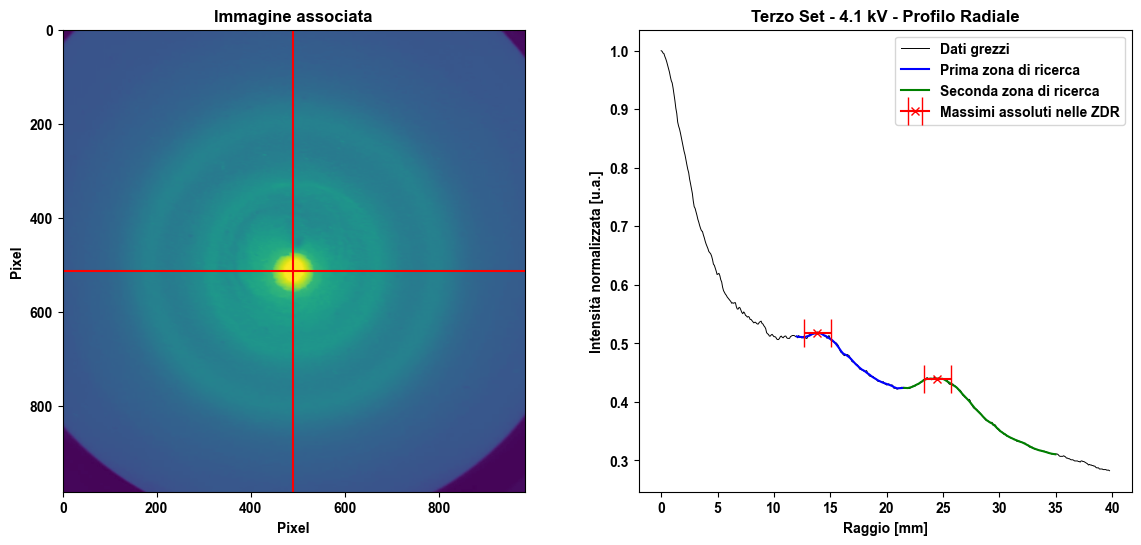

0.08133387555917039


(983, 983)

In [166]:
#PLOT ESEMPLIFICATIVO PER UN FILE
file='4100_v.jpeg'

x=risultati[file]['R_Mesh'][:-2]
x=x*risultati[file]['Pixel_in_mm']
y=risultati[file]['Fold'][:-2]

#array di y passato sotto la media mobile
y_med=media_mobile_conv(y, 9)

#fette di dati tra le rette di soglia definite arbitrariamente
cut_1_x, cut_1_y = taglia_dati(x, y_med, retta_1, retta_2)
cut_2_x, cut_2_y = taglia_dati(x, y_med, retta_2, 35)


plt.figure(figsize=(14,6))
plt.subplot(122)
plt.title('Terzo Set - 4.1 kV - Profilo Radiale')
plt.xlabel('Raggio [mm]')
plt.ylabel('Intensità normalizzata [u.a.]')

#dati originari
plt.plot(
            x, 
            y,
            linewidth=.7, 
            c='black'
        )

#fette di dati passate sotto media mobile
plt.plot(cut_1_x, cut_1_y, c='blue')
plt.plot(cut_2_x, cut_2_y, c='green')   

#indici dei massimi locali all'interno delle fette
max_1=np.argmax(cut_1_y)
max_2=np.argmax(cut_2_y)

#inserimento dei massimi
plt.errorbar(cut_1_x[max_1], cut_1_y[max_1],xerr=err, c='red', capsize=10, marker='x')    
plt.errorbar(cut_2_x[max_2], cut_2_y[max_2],xerr=err, c='red', capsize=10, marker='x')


plt.legend(('Dati grezzi', 'Prima zona di ricerca', 'Seconda zona di ricerca', 'Massimi assoluti nelle ZDR'))

plt.subplot(121)
plt.title('Immagine associata')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.scatter(risultati[file]['Riga_Centro']-3,risultati[file]['Colonna_Centro']+20, marker='+', s=200000, c='r')

plt.imshow(risultati[file]['Matrice'])


plt.show()

print(risultati[file]['Pixel_in_mm'])
risultati[file]['Matrice'].shape

In [167]:
R10=[]
R11=[]
print('set\tV\t\tR10\t\t\tR11')
for file in risultati:
    R10.append((risultati[file]['R10']))
    R11.append((risultati[file]['R11']))
    print( risultati[file]['Set'],'\t', risultati[file]['Voltaggio'], '\t' ,risultati[file]['R10'], '\t', risultati[file]['R11'])

set	V		R10			R11
v 	 3400.0 	 0.015922014622258326 	 0.0281072298943948
v 	 3800.0 	 0.014535119772634999 	 0.025578562728380026
v 	 4100.0 	 0.013826758845058967 	 0.024481496543310288
v 	 4350.0 	 0.013512413512413512 	 0.024582824582824583
v 	 4500.0 	 0.012981744421906694 	 0.02288032454361055


## Calcolo delle varie $\lambda$ e propagazione errori

In [168]:
for file in risultati:
    risultati[file]['R10_err']=1.2/1000
    risultati[file]['R11_err']=1.2/1000
    risultati[file]['Voltaggio_err']=50
    risultati[file]['Lambda_De_Broglie']= h / np.sqrt(2*m_e*e*risultati[file]['Voltaggio'])
    risultati[file]['Lambda_De_Broglie_err'] =  ((h / np.sqrt(2*m_e*e)) * ( 1 / (2*((risultati[file]['Voltaggio'])**(3/2))) )) * risultati[file]['Voltaggio_err']
    risultati[file]['Lambda_Bragg_10']=d_10*risultati[file]['R10']/L
    risultati[file]['Lambda_Bragg_11']=D_11*risultati[file]['R11']/L
    risultati[file]['Lambda_Bragg_10_err']= np.sqrt(
                                                        (d_10 * risultati[file]['R10_err']/L)**2 
                                                        +((d_10 * risultati[file]['R10'] * L_err)/(L**2))**2
                                                    )
    risultati[file]['Lambda_Bragg_11_err']= np.sqrt(
                                                        (D_11 * risultati[file]['R11_err']/L)**2
                                                        +(D_11 * risultati[file]['R11'] * L_err /(L**2))**2
                                                    )


In [169]:
for file in risultati:
    
    risultati[file]['Lambda_Bragg_10_test']=d_10*np.sin(np.arctan(risultati[file]['R10']/(L-(R-np.sqrt(R**2 -risultati[file]['R10']**2)))))
    risultati[file]['Lambda_Bragg_11_test']=D_11*np.sin(np.arctan(risultati[file]['R11']/(L-(R-np.sqrt(R**2 -risultati[file]['R11']**2)))))

## Grafico
Stile grafico copiato dal codice fatto da dario, tranne per i ticks che non ho capito

In [170]:
#PREPARAZIONE PLOT kV vs nm
x=[]
x_err=[]
L_DB=[]
L_DB_err=[]
L_B_10=[]
L_B_11=[]
L_B_10_err=[]
L_B_11_err=[]
L_B_10_test=[]
L_B_11_test=[]

for i in risultati:
    x.append(risultati[i]['Voltaggio'] *   10**-3)
    x_err.append(risultati[i]['Voltaggio_err'] *   10**-3)
    L_DB.append(risultati[i]['Lambda_De_Broglie']  *   10**12)
    L_DB_err.append(risultati[i]['Lambda_De_Broglie_err']  *   10**12)
    L_B_10.append(risultati[i]['Lambda_Bragg_10']  *   10**12)
    L_B_11.append(risultati[i]['Lambda_Bragg_11']  *   10**12)
    L_B_10_err.append(risultati[i]['Lambda_Bragg_10_err']  *   10**12)
    L_B_11_err.append(risultati[i]['Lambda_Bragg_11_err']  *   10**12)
    L_B_10_test.append(risultati[i]['Lambda_Bragg_10_test']  *   10**12)
    L_B_11_test.append(risultati[i]['Lambda_Bragg_11_test']  *   10**12)
    


In [171]:
print(L_B_10_test)
print(L_B_10)

[np.float64(27.122619660238865), np.float64(24.76138612459878), np.float64(23.555239473464216), np.float64(23.01996610536864), np.float64(22.116294201165648)]
[np.float64(27.131112916328192), np.float64(24.76784409257004), np.float64(23.56079707198048), np.float64(23.02515262515263), np.float64(22.120892494929006)]


In [172]:
x

[3.4, 3.8000000000000003, 4.1, 4.3500000000000005, 4.5]

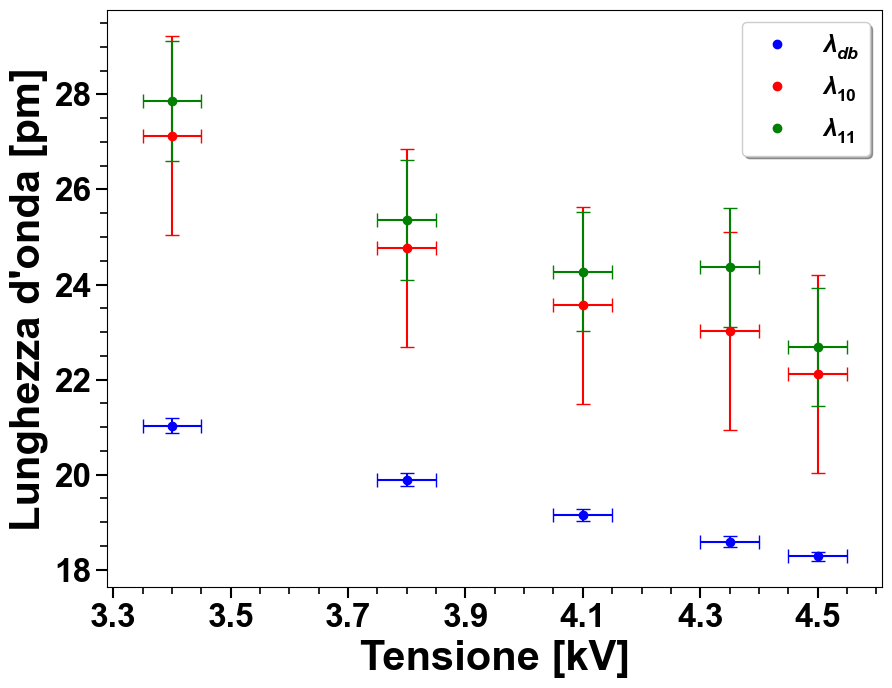

In [173]:
#PLOT

plt.figure(figsize=(10, 7.5))
if titoli:
    plt.title('Confronto Lunghezze d\'Onda - Bragg e de Broglie', fontsize=30)
# Plottiamo i punti sperimentali del Set 1 (Pallini Rossi)
plt.errorbar(x, L_DB, xerr=x_err , yerr=L_DB_err, fmt='bo',capsize=5,)

plt.errorbar(x, L_B_10, xerr=x_err , yerr=L_B_10_err, fmt='ro', capsize=5,)
#plt.errorbar(x, L_B_10_test, xerr=x_err , fmt='y o', capsize=5,)
#plt.errorbar(x, L_B_11_test, xerr=x_err , fmt='y o', capsize=5,)

plt.errorbar(x, L_B_11, xerr=x_err , yerr=L_B_11_err, fmt='go', capsize=5)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'bo',label=r'$\lambda_{db}$')
plt.plot([], [], 'ro', label=r'$\lambda_{10}$')
plt.plot([], [], 'go', label=r'$\lambda_{11}$')


# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(3.3, 4.6, 0.2) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(0.018e3, 0.030e3, 0.002e3)
ax.set_yticks(tick_y_manuali)

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)




plt.xlabel("Tensione [kV]",fontsize=30) # <--- Ricorda di aggiornare l'etichetta
plt.ylabel("Lunghezza d'onda [pm]",fontsize=30)
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=18)
#plt.savefig("GRAFICI/confronto_lambda_2.png", dpi=300, bbox_inches='tight')
plt.show()